In [14]:
import torch
from torchvision import transforms
from pathlib import Path
from PIL import Image

def load_data(data_dir="", size=512, center_crop=True) -> torch.Tensor:
    image_transforms = transforms.Compose(
        [
            transforms.Resize(size, interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.CenterCrop(size) if center_crop else transforms.RandomCrop(size),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),
        ]
    )
    
    if Path(data_dir).is_file():  # 检查data_dir是否为单个文件
        # 加载单个图像并重复4次
        image = Image.open(data_dir).convert("RGB")
        images = [image_transforms(image) for _ in range(4)]
    else:  # data_dir是目录
        images = [image_transforms(Image.open(i).convert("RGB")) for i in list(Path(data_dir).iterdir())]

    images = torch.stack(images)
    return images

In [17]:
# 保护后图像的路径
ted_protected_images = "/data1/humw/Codes/My-Anti-DreamBooth/outputs/adversarial_images/Encoder_attack_conda-photomaker_VGGFace2_vae15-ipadapter-photomaker_mix_eot-0_yingbu_agm-2_norm-0/n000050"
idprotector_protected_images = "/data1/humw/Codes/My-Anti-DreamBooth/outputs/adversarial_images/IDProtector_conda-photomaker_VGGFace2_vae15-ipadapter-photomaker_cosine_eot-0_non-target_agm-2_norm-0/n000050"
# 原始图像的路径
original_images = "/data1/humw/Codes/My-Anti-DreamBooth/outputs/adversarial_images/VGGFace2/n000050/set_B"

ted_image_tensors = load_data(data_dir=ted_protected_images)
idprotector_image_tensors = load_data(data_dir=idprotector_protected_images)
original_image_tensors = load_data(data_dir=original_images)

In [18]:
ted_et = ted_image_tensors - original_image_tensors
idprotector_et = idprotector_image_tensors - original_image_tensors

In [20]:
print(ted_et.min())
print(ted_et.max())
print(ted_et.shape)

tensor(-0.1255)
tensor(0.1333)
torch.Size([4, 3, 512, 512])


In [23]:
one_image_ted_et = ted_et[0]
one_image_idprotector_et = idprotector_et[0]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.12549025..0.13333338].


torch.Size([3, 512, 512])
torch.Size([3, 512, 512])


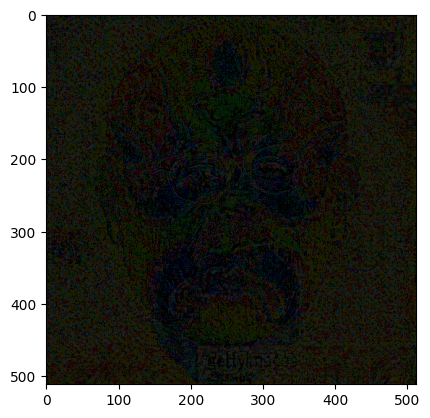

In [24]:
# 使用opencv库可视化ted_et
import cv2
import matplotlib.pyplot as plt

print(one_image_ted_et.shape)
one_image_ted_et = one_image_ted_et.squeeze(0)
print(one_image_ted_et.shape)
plt.imshow(one_image_ted_et.permute(1, 2, 0))
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.12549025..0.13333338].


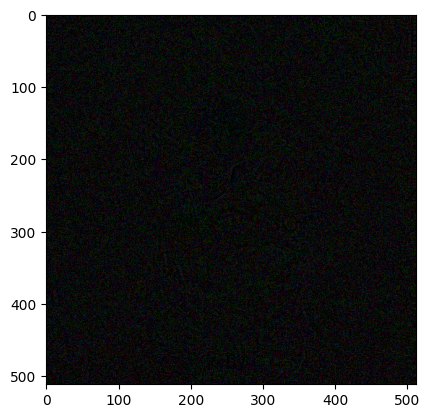

In [25]:
# 使用opencv库可视化ted_et
import cv2
import matplotlib.pyplot as plt

one_image_idprotector_et = one_image_idprotector_et.squeeze(0)
plt.imshow(one_image_idprotector_et.permute(1, 2, 0))
plt.show()

In [28]:
ted_mist_protected_images = "/data1/humw/Codes/My-Anti-DreamBooth/outputs/adversarial_images/Encoder_attack_conda-photomaker_VGGFace2_vae15-ipadapter-photomaker_mix_eot-0_mist_agm-2_norm-0/n000050"
ted_mist_image_tensors = load_data(data_dir=ted_mist_protected_images)
ted_mist_et = ted_mist_image_tensors - original_image_tensors
one_image_ted_mist_et = ted_mist_et[0]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.12549025..0.13333338].


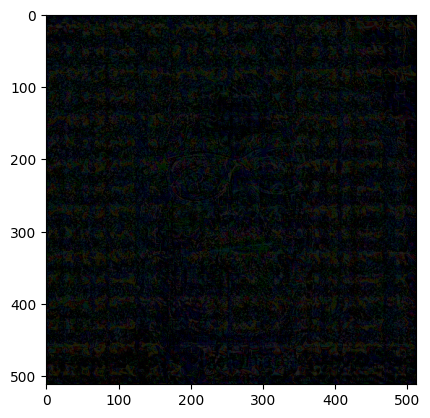

In [29]:
# 使用opencv库可视化ted_et
import cv2
import matplotlib.pyplot as plt

one_image_ted_mist_et = one_image_ted_mist_et.squeeze(0)
plt.imshow(one_image_ted_mist_et.permute(1, 2, 0))
plt.show()

In [30]:
ted_face_protected_images = "/data1/humw/Codes/My-Anti-DreamBooth/outputs/adversarial_images/Encoder_attack_conda-photomaker_VGGFace2_vae15-ipadapter-photomaker_mix_eot-0_face_agm-2_norm-0/n000050"
ted_face_image_tensors = load_data(data_dir=ted_face_protected_images)
ted_face_et = ted_face_image_tensors - original_image_tensors
one_image_ted_face_et = ted_face_et[0]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.12549025..0.13333338].


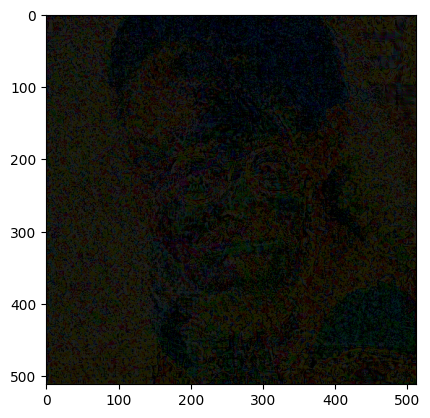

In [31]:
# 使用opencv库可视化ted_et
import cv2
import matplotlib.pyplot as plt

one_image_ted_face_et = one_image_ted_face_et.squeeze(0)
plt.imshow(one_image_ted_face_et.permute(1, 2, 0))
plt.show()

In [32]:
ted_gray_protected_images = "/data1/humw/Codes/My-Anti-DreamBooth/outputs/adversarial_images/Encoder_attack_conda-photomaker_VGGFace2_vae15-ipadapter-photomaker_mix_eot-0_gray_agm-2_norm-0/n000050"
ted_gray_image_tensors = load_data(data_dir=ted_gray_protected_images)
ted_gray_et = ted_gray_image_tensors - original_image_tensors
one_image_ted_gray_et = ted_gray_et[0]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.12549025..0.13333338].


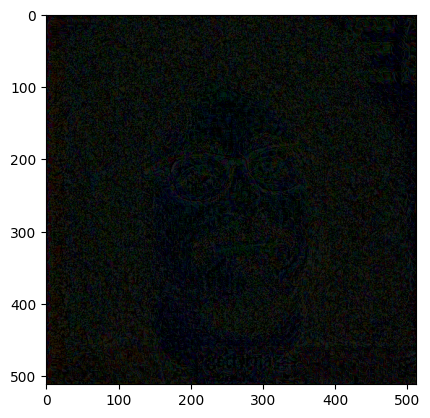

In [33]:
# 使用opencv库可视化ted_et
import cv2
import matplotlib.pyplot as plt

one_image_ted_gray_et = one_image_ted_gray_et.squeeze(0)
plt.imshow(one_image_ted_gray_et.permute(1, 2, 0))
plt.show()